In [ ]:
# File Path

# D:\Problem_Solving_Practice\Deep_Learning\Deep_Learning_Codes\DL_Projects\3.Loan-Default-Classification-ANN

In [16]:
%pip install -U pandas numpy matplotlib seaborn scikit-learn joblib tensorflow

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl.metadata (60 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl (8.9 MB)
Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl (41.3 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ ------------------

In [1]:
# Install once if needed
# %pip install pandas numpy matplotlib seaborn scikit-learn tensorflow joblib

import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                            roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(tf.__version__)

2.21.0


In [3]:
# Change this path if your file has another name
DATA_PATH = r"D:\Problem_Solving_Practice\Deep_Learning\Deep_Learning_Codes\DL_Projects\3.Loan-Default-Classification-ANN\Loan_Default.csv"

df = pd.read_csv(DATA_PATH)

df.columns = df.columns.str.strip()

print("Shape:", df.shape)
display(df.head())

Shape: (148670, 34)


,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [ ]:
# Standardize column names and repair common spelling variants
rename_map = {
    "Gender":"gender", "Credit_Worthiness":"credit_worthiness",
    "Interest_rate_spread":"interest_rate_spread", "Upfront_charges":"upfront_charges",
    "term":"loan_term_months", "Neg_ammortization":"negative_amortization",
    "Secured_by":"secured_by", "Credit_Score":"credit_score", "Region":"region",
    "Security_Type":"security_type", "Status":"status", "dtir1":"debt_to_income_ratio"
}
df = df.rename(columns=rename_map)
df.columns = (df.columns.str.strip().str.lower().str.replace(r"[^a-z0-9]+", "_", regex=True).str.strip("_"))

# Remove duplicate rows and normalize missing markers
df = df.drop_duplicates().copy()
df = df.replace(["", " ", "NA", "N/A", "na", "null", "None"], np.nan)
if "status" not in df.columns:
    raise ValueError("Target column Status/status was not found.")
df["status"] = pd.to_numeric(df["status"], errors="coerce")
df = df[df["status"].isin([0, 1])].copy()
print(df.shape)
print(df.isna().sum().sort_values(ascending=False).head(15))

(148670, 34)
upfront_charges              39642
interest_rate_spread         36639
rate_of_interest             36439
debt_to_income_ratio         24121
property_value               15098
ltv                          15098
income                        9150
loan_limit                    3344
approv_in_adv                  908
age                            200
submission_of_application      200
loan_purpose                   134
negative_amortization          121
loan_term_months                41
year                             0
dtype: int64


### EDA

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,148670.0,NaN,NaN,NaN,99224.5,42917.476598,24890.0,62057.25,99224.5,136391.75,173559.0
year,148670.0,NaN,NaN,NaN,2019.0,0.0,2019.0,2019.0,2019.0,2019.0,2019.0
loan_limit,145326,2,cf,135348,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,148670,4,Male,42346,NaN,NaN,NaN,NaN,NaN,NaN,NaN
approv_in_adv,147762,2,nopre,124621,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_type,148670,3,type1,113173,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_purpose,148536,4,p3,55934,NaN,NaN,NaN,NaN,NaN,NaN,NaN
credit_worthiness,148670,2,l1,142344,NaN,NaN,NaN,NaN,NaN,NaN,NaN
open_credit,148670,2,nopc,148114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
business_or_commercial,148670,2,nob/c,127908,NaN,NaN,NaN,NaN,NaN,NaN,NaN


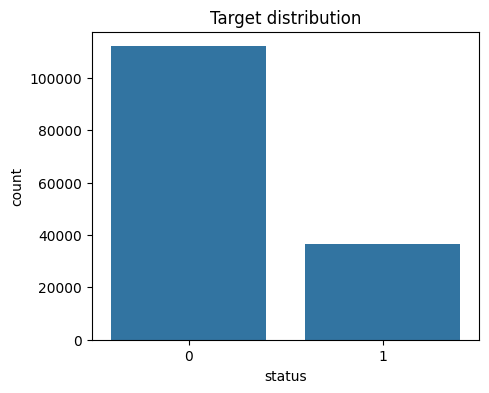

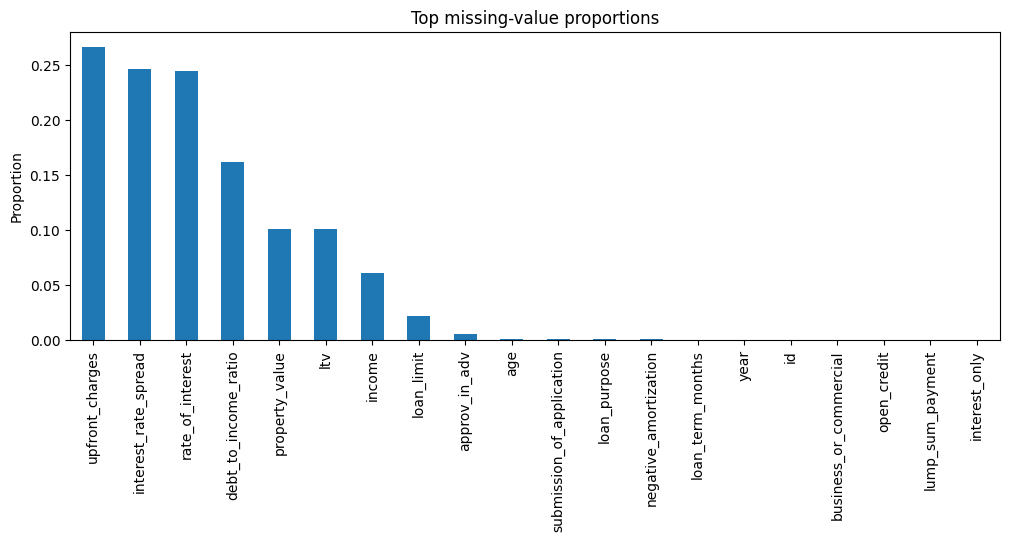

In [5]:
display(df.describe(include="all").T)
plt.figure(figsize=(5,4)); sns.countplot(data=df, x="status"); plt.title("Target distribution"); plt.show()
missing = df.isna().mean().sort_values(ascending=False).head(20)
missing.plot(kind="bar", figsize=(12,4), title="Top missing-value proportions"); plt.ylabel("Proportion"); plt.show()

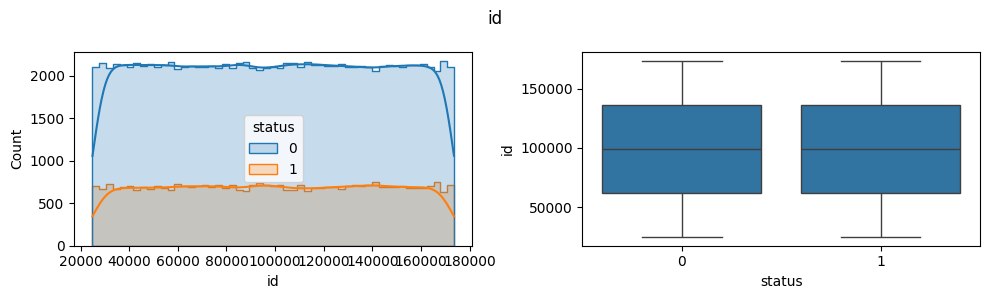

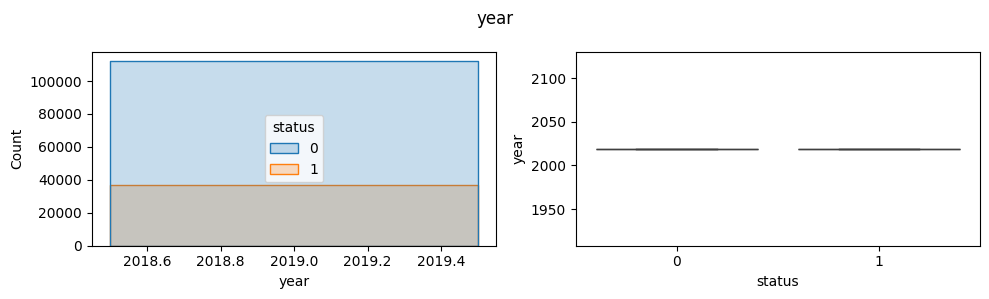

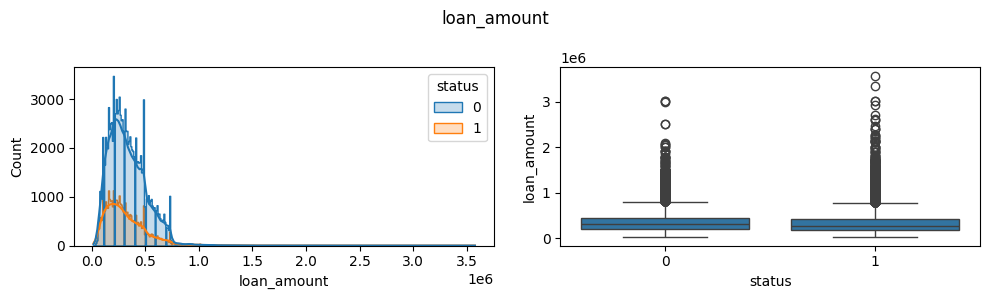

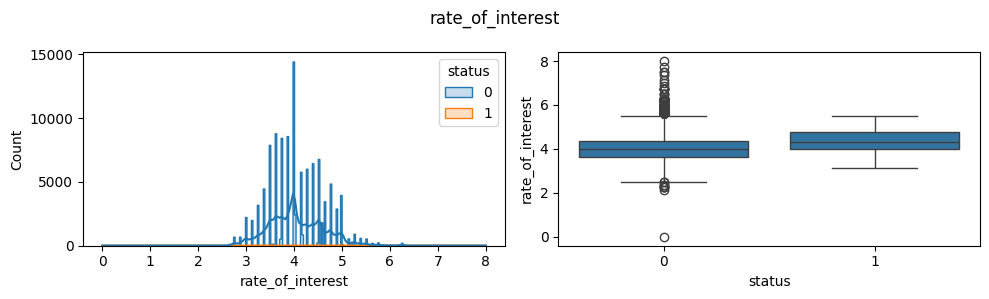

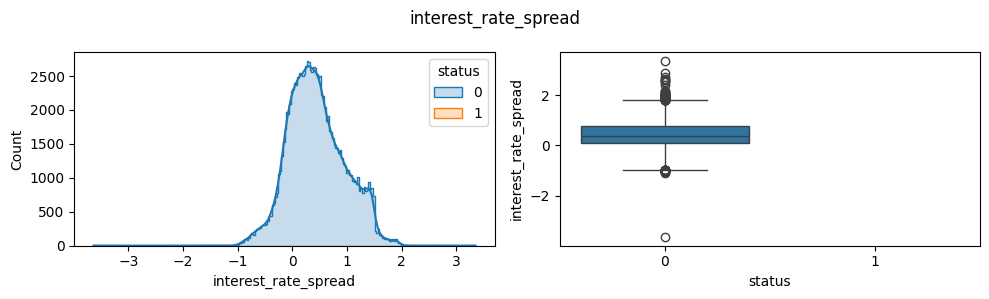

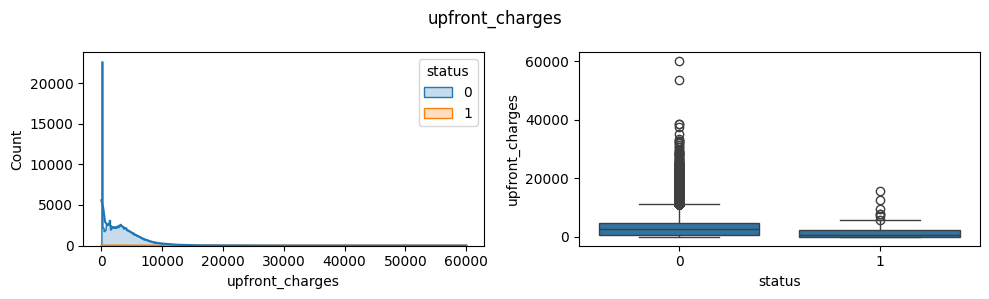

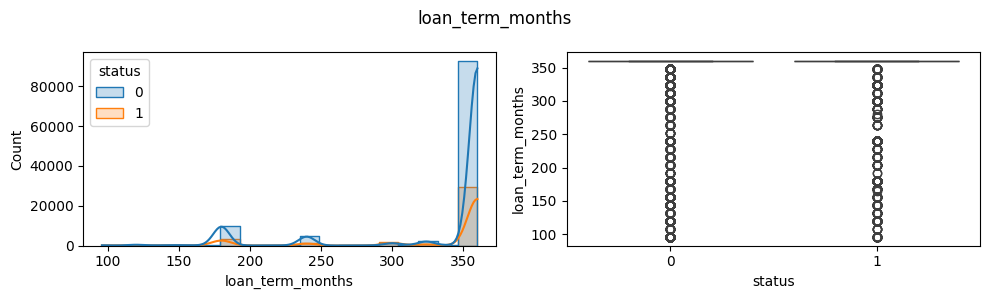

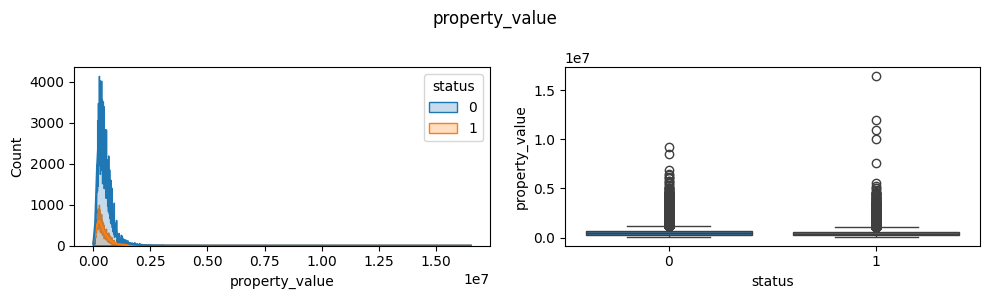

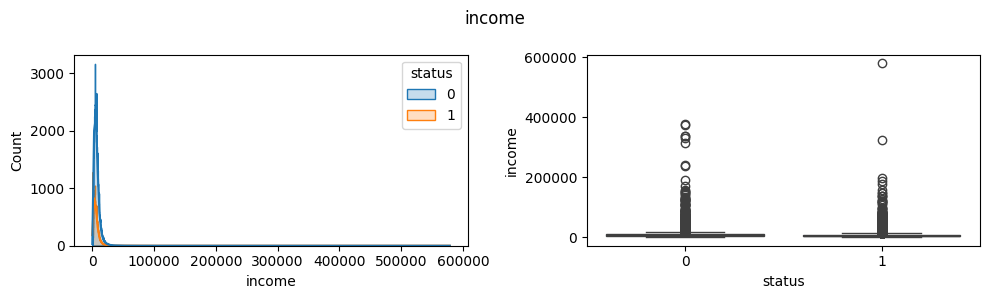

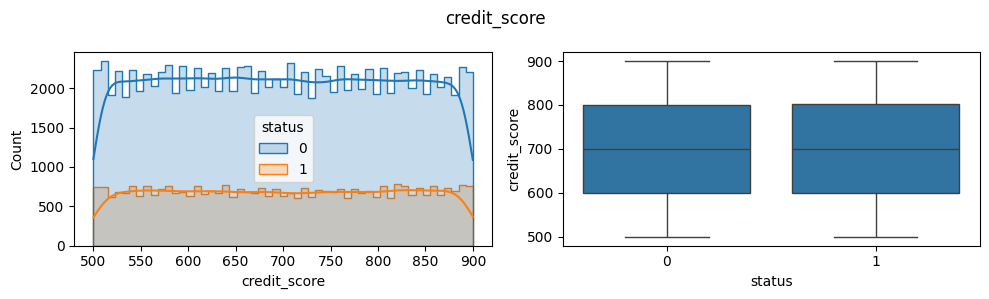

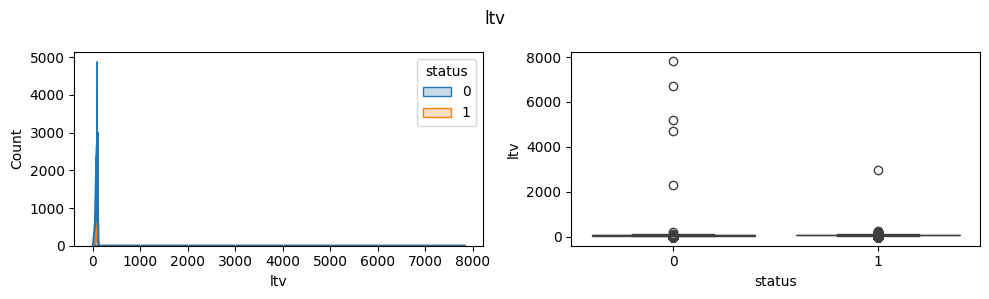

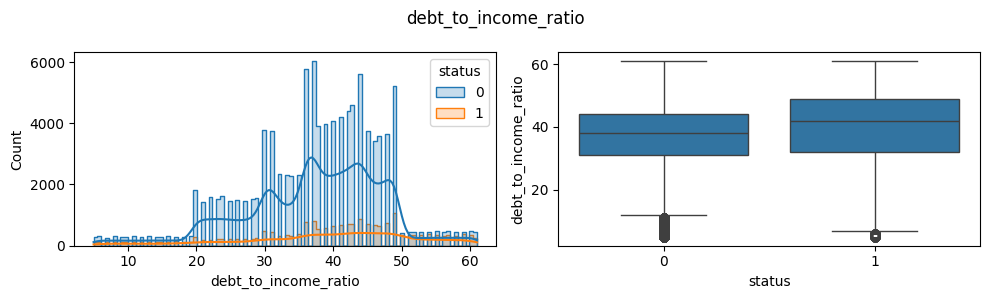

In [6]:
# Numeric EDA: distributions and target relationship
num_for_eda = df.select_dtypes(include=np.number).columns.tolist()
num_for_eda = [c for c in num_for_eda if c != "status"][:12]
for c in num_for_eda:
    fig, ax = plt.subplots(1, 2, figsize=(10,3))
    sns.histplot(data=df, x=c, hue="status", kde=True, element="step", ax=ax[0])
    sns.boxplot(data=df, x="status", y=c, ax=ax[1])
    fig.suptitle(c); plt.tight_layout(); plt.show()

###  Prepare data and split

In [7]:
X = df.drop(columns="status")
y = df["status"].astype("int32")
# Stratification preserves the default/non-default ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()
print("Numeric:", num_cols)
print("Categorical:", cat_cols)

Numeric: ['id', 'year', 'loan_amount', 'rate_of_interest', 'interest_rate_spread', 'upfront_charges', 'loan_term_months', 'property_value', 'income', 'credit_score', 'ltv', 'debt_to_income_ratio']
Categorical: ['loan_limit', 'gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'credit_worthiness', 'open_credit', 'business_or_commercial', 'negative_amortization', 'interest_only', 'lump_sum_payment', 'construction_type', 'occupancy_type', 'secured_by', 'total_units', 'credit_type', 'co_applicant_credit_type', 'age', 'submission_of_application', 'region', 'security_type']


In [8]:
# Version-compatible OneHotEncoder
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
cat_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", ohe)])
preprocessor = ColumnTransformer([("num", num_pipe, num_cols), ("cat", cat_pipe, cat_cols)], remainder="drop")

# Fit only on training data: prevents test-set leakage
X_train_pre = preprocessor.fit_transform(X_train).astype("float32")
X_test_pre = preprocessor.transform(X_test).astype("float32")
feature_names = preprocessor.get_feature_names_out()
selector = VarianceThreshold(threshold=0.01)
X_train_final = selector.fit_transform(X_train_pre).astype("float32")
X_test_final = selector.transform(X_test_pre).astype("float32")
selected_names = feature_names[selector.get_support()]
print("Before selection:", X_train_pre.shape)
print("After selection:", X_train_final.shape)
print("Removed:", X_train_pre.shape[1] - X_train_final.shape[1])

Before selection: (118936, 71)
After selection: (118936, 57)
Removed: 14


## ANN: ReLU, batch normalization, dropout, sigmoid

In [9]:
# Binary classification architecture
# ReLU: hidden nonlinearities; BatchNormalization: stable activations;
# Dropout: regularization; Sigmoid: probability of default.
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_final.shape[1],)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.30),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.20),
    tf.keras.layers.Dense(1, activation="sigmoid")
])
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss="binary_crossentropy", metrics=[tf.keras.metrics.BinaryAccuracy(name="accuracy"), tf.keras.metrics.AUC(name="auc")])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         7,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,513 (64.50 KB)

 Trainable params: 16,129 (63.00 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/60
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9984 - auc: 0.9998 - loss: 0.0064 - val_accuracy: 0.9986 - val_auc: 0.9997 - val_loss: 0.0196 - learning_rate: 6.2500e-05
Epoch 2/60
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9987 - auc: 0.9998 - loss: 0.0061 - val_accuracy: 0.9986 - val_auc: 0.9997 - val_loss: 0.0190 - learning_rate: 6.2500e-05
Epoch 3/60
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9985 - auc: 0.9998 - loss: 0.0063 - val_accuracy: 0.9987 - val_auc: 0.9997 - val_loss: 0.0181 - learning_rate: 6.2500e-05
Epoch 4/60
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9987 - auc: 0.9999 - loss: 0.0054 - val_accuracy: 0.9988 - val_auc: 0.9997 - val_loss: 0.0175 - learning_rate: 6.2500e-05
Epoch 5/60
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9986 - auc: 0.9999 - loss: 0.0055 - val_accuracy: 0.9988 - val_auc: 0.9997 - val_loss: 0.0184 - learning_rate: 6.2500e-05
Epoch 6/60
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accura

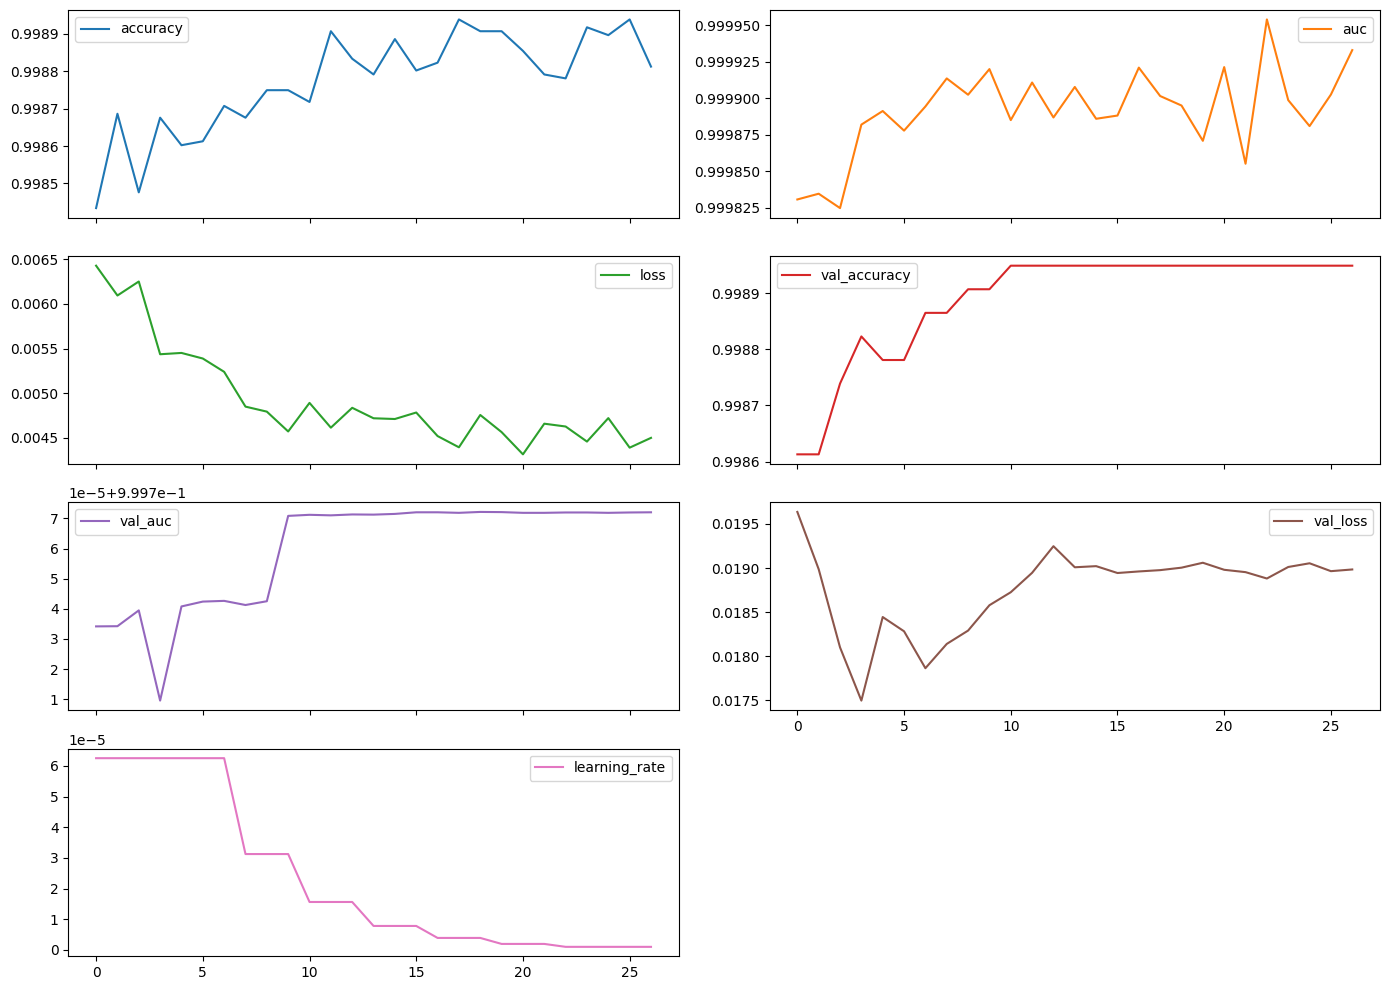

In [15]:
# Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=8,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6
    )
]

# Train the ANN model
history = model.fit(
    X_train_final,
    y_train.to_numpy(),
    validation_split=0.20,
    epochs=60,
    batch_size=256,
    class_weight=None,
    callbacks=callbacks,
    verbose=1
)

# Convert training history to DataFrame
history_df = pd.DataFrame(history.history)

# Display available metrics
print("Metrics available:")
print(history_df.columns.tolist())

# Plot all training metrics
history_df.plot(
    figsize=(14, 10),
    subplots=True,
    layout=(4, 2)
)

plt.tight_layout()
plt.show()

## Evaluation

,score
accuracy,0.998554
precision,0.994703
recall,0.999454
f1,0.997073
roc_auc,0.999875


              precision    recall  f1-score   support

           0     0.9998    0.9983    0.9990     22406
           1     0.9947    0.9995    0.9971      7328

    accuracy                         0.9986     29734
   macro avg     0.9973    0.9989    0.9981     29734
weighted avg     0.9986    0.9986    0.9986     29734



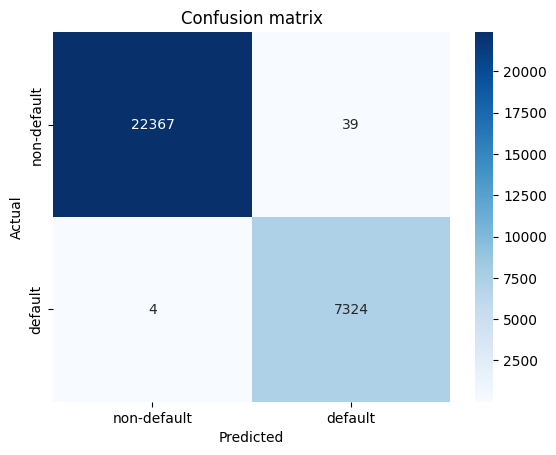

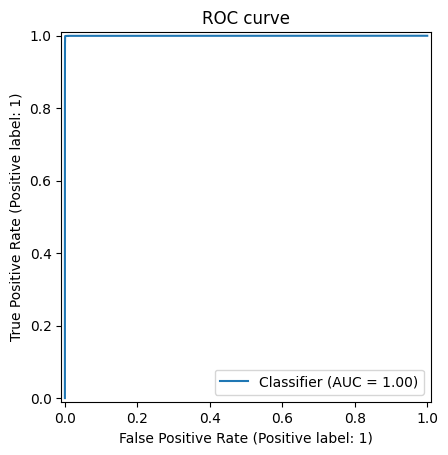

In [16]:
prob = model.predict(X_test_final, verbose=0).ravel()
threshold = 0.50
pred = (prob >= threshold).astype(int)
metrics = {
    "accuracy": accuracy_score(y_test, pred),
    "precision": precision_score(y_test, pred, zero_division=0),
    "recall": recall_score(y_test, pred, zero_division=0),
    "f1": f1_score(y_test, pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, prob)
}
display(pd.DataFrame([metrics]).T.rename(columns={0:"score"}))
print(classification_report(y_test, pred, digits=4, zero_division=0))
cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["non-default","default"], yticklabels=["non-default","default"])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion matrix"); plt.show()
RocCurveDisplay.from_predictions(y_test, prob); plt.title("ROC curve"); plt.show()

## Predict new loan records

In [17]:
# Supply one or more dictionaries using the ORIGINAL dataset column names or cleaned names.
# Missing fields are allowed and will be imputed; unknown categories are ignored.
new_loan = pd.DataFrame([{
    "year": 2019, "loan_limit": "cf", "gender": "Male", "approv_in_adv": "nopre",
    "loan_type": "type1", "loan_purpose": "p1", "credit_worthiness": "l1",
    "open_credit": "nopc", "business_or_commercial": "nob/c",
    "loan_amount": 250000, "rate_of_interest": 4.0, "interest_rate_spread": 0.4,
    "upfront_charges": 3000, "loan_term_months": 360, "property_value": 350000,
    "income": 8000, "credit_score": 720, "co_applicant_credit_type": "CIB",
    "age": "35-44", "submission_of_application": "to_inst", "LTV": 71.4,
    "region": "North", "security_type": "direct", "debt_to_income_ratio": 35
}])
# Ensure exactly the training columns; extra columns are discarded.
new_loan = new_loan.reindex(columns=X_train.columns)
new_pre = preprocessor.transform(new_loan).astype("float32")
new_final = selector.transform(new_pre).astype("float32")
new_prob = float(model.predict(new_final, verbose=0).ravel()[0])
print({"default_probability": round(new_prob, 4), "prediction": int(new_prob >= threshold),
       "label": "default" if new_prob >= threshold else "non-default"})

{'default_probability': 0.1777, 'prediction': 0, 'label': 'non-default'}


## Save and reload artifacts

In [18]:
joblib.dump({"preprocessor": preprocessor, "selector": selector, "threshold": threshold, "columns": X_train.columns.tolist()}, "loan_preprocessing.joblib")
model.save("loan_default_ann.keras")
print("Saved loan_preprocessing.joblib and loan_default_ann.keras")

Saved loan_preprocessing.joblib and loan_default_ann.keras


## Algorithm workflow

1. Read CSV and normalize column names.
2. Remove duplicates, normalize missing markers, and validate binary target.
3. Split before fitting preprocessing.
4. Median-impute and scale numeric features; most-frequent-impute and one-hot encode categorical features.
5. Apply `VarianceThreshold(0.01)` fitted on training data only.
6. Train an ANN using forward propagation, binary cross-entropy, gradients from backpropagation, and Adam updates.
7. Use ReLU in hidden layers, batch normalization and dropout for regularization, and sigmoid for the binary output.
8. Evaluate at a 0.50 threshold using accuracy, precision, recall, F1, ROC-AUC, and confusion matrix.

For an imbalanced lending dataset, do not rely on accuracy alone; inspect recall, precision, ROC-AUC, and the confusion matrix. The threshold can be changed according to the business cost of missed defaults versus false alarms.

1. Problem framing
You want to predict whether a loan applicant will default (1) or not default (0) using their financial and loan characteristics.

Input: tabular features (numeric + categorical).

Output: binary label status.

Goal: train a model that estimates 
𝑃
(
default
∣
features
)
P(default∣features) and then threshold this probability to get a class prediction.

2. Overall pipeline overview
The project follows this pipeline:

1.Load raw CSV data.

2.Clean and standardize column names.

3.Handle duplicates and missing-value markers.

4.Validate and prepare the target column.

5.Exploratory data analysis (EDA).

6.Split data into train/test (stratified).

7.Preprocess features:

- Impute missing values.

- Scale numeric features.

- One-hot encode categorical features.

8.Apply feature selection with VarianceThreshold.

9.Build an Artificial Neural Network (ANN).

.Compile with Adam and binary cross-entropy.



10.Train the ANN with Adam optimizer and backpropagation.

11.Evaluate using accuracy, precision, recall, F1, ROC-AUC, and confusion matrix.

12.Use the trained pipeline to predict on new loan records.

13.Save model and preprocessing objects for reuse.